<h2 style = "color:green">INTRODUCTION

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The Tech Layoffs 2026 | AI Job Cuts Tracker dataset compiles verified layoff events from 28 major technology companies between January and March 2026, covering roughly 85,000 confirmed job cuts (up to ~101,000 when including planned reductions like Meta's). What sets this dataset apart from typical layoff trackers is its explicit focus on AI attribution — whether a company publicly cited artificial intelligence as a driver of workforce reduction, alongside financial context like revenue, AI capital expenditure, and stock market reaction on the day of announcement.
The dataset is compiled from cross-verified sources (Layoffs.fyi, CNBC, NetworkWorld, TechRepublic, Crunchbase, IBTimes, and others), and includes both quantitative fields (jobs cut, % of workforce, revenue, stock change) and qualitative fields (CEO quotes, roles affected, replacement roles), spanning 10 countries and multiple sectors — enterprise software, e-commerce/cloud, telecom, fintech, semiconductors, and social media/AI.
The dataset frames a specific narrative worth testing rather than assuming: companies cutting tens of thousands of jobs are, in the same period, committing hundreds of billions of dollars to AI infrastructure. Whether this represents direct substitution, coincidental timing, or narrative-driven corporate messaging is exactly the kind of question EDA is suited to interrogate before jumping to conclusions.

<h2 style = "color:green">OBJECTIVES:

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">
<ul>
<li>Data cleaning & structuring — handle missing values, standardize date/percentage/currency fields, verify consistency between jobs_cut, pct_workforce_cut, and pre_layoff_headcount.
<li>Univariate analysis — distribution of layoffs by company, sector, country, month, and layoff-size category.
<li>AI attribution analysis — compare AI-cited vs. non-AI-cited layoffs across size, sector, and stock reaction; check which sectors report the highest AI-cited layoff share.
<li>Market reaction analysis — test whether AI-cited layoffs correlate with more positive stock reactions (the "efficiency signal" hypothesis) versus non-AI-cited cuts.
<li>Financial correlation — examine relationships between company revenue, AI capex (simultaneous_ai_investment_bn), and layoff <li>scale — does higher AI investment coincide with larger cuts, smaller cuts, or no clear pattern?
<li>Time trend — assess whether layoff frequency/size is increasing or decreasing across Jan–Mar 2026.
<li>Sector risk profiling — identify which sectors appear most exposed to AI-driven job cuts based on current data.
</ul>
</div>

<h3 style = "color:green">Getting Ready With Dataset

In [1]:
import numpy as np
import pandas as pd
import polars as pl

import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so



In [2]:
data = pl.read_csv('/home/kartika/Datasets/tech_layoffs_2026_tracker.csv')
data = data.to_pandas()
data.head()

,company,layoff_date,jobs_cut,pct_workforce_cut,sector,country,hq_city,ai_cited,reason_stated,company_revenue_2025_bn,...,layoffs_2024,layoffs_2025,verified_source,month,quarter,region,layoff_size_category,stock_reaction,laid_off_vs_headcount_pct,data_as_of
0,Amazon,2026-01-15,16000,2.7,E-Commerce/Cloud,USA,Seattle,False,Reduce bureaucracy and management layers,716.9,...,4000,14000,CNBC / NetworkWorld,January 2026,Q1 2026,North America,Mega (5K+),Positive,1.03,"March 18, 2026"
1,Block,2026-02-28,4000,40.0,Fintech,USA,San Francisco,True,AI tools replace roles enabling smaller teams,22.4,...,0,1000,CNBC / Crunchbase,February 2026,Q1 2026,North America,Large (2K-5K),Positive,40.00,"March 18, 2026"
2,Meta Reality Labs,2026-01-20,1500,10.0,Social Media/VR,USA,Menlo Park,True,Pivot from metaverse to AI research,164.5,...,0,500,InformationWeek / NYT,January 2026,Q1 2026,North America,Medium (500-2K),Positive,1.90,"March 18, 2026"
3,Atlassian,2026-03-14,1600,10.0,Enterprise Software,Australia,Sydney,True,Pivot to AI-first company strategy,5.1,...,0,500,TechRepublic / Metaintro,March 2026,Q1 2026,Asia-Pacific,Medium (500-2K),Positive,10.00,"March 18, 2026"
4,Oracle,2026-02-01,30000,15.0,Enterprise Software,USA,Austin,True,AI data centres replace human ops,52.9,...,6000,10000,IBTimes,February 2026,Q1 2026,North America,Mega (5K+),Positive,15.00,"March 18, 2026"


In [3]:
data.tail()

,company,layoff_date,jobs_cut,pct_workforce_cut,sector,country,hq_city,ai_cited,reason_stated,company_revenue_2025_bn,...,layoffs_2024,layoffs_2025,verified_source,month,quarter,region,layoff_size_category,stock_reaction,laid_off_vs_headcount_pct,data_as_of
23,Workday,2026-01-28,2200,8.5,Enterprise SaaS,USA,Pleasanton CA,True,AI investment and office space reduction,8.5,...,1750,1750,Computerworld,January 2026,Q1 2026,North America,Large (2K-5K),Positive,8.53,"March 18, 2026"
24,Ergo Insurance,2026-03-01,200,2.0,Insurance,Germany,Dusseldorf,True,AI automates insurance tasks,0.0,...,0,0,Intellizence,March 2026,Q1 2026,Europe,Small (<500),Neutral,2.22,"March 18, 2026"
25,Algoma Steel,2026-03-07,1000,20.0,Manufacturing,Canada,Sault Ste Marie,False,Blast furnace closure,2.8,...,0,0,Intellizence,March 2026,Q1 2026,North America,Medium (500-2K),Negative,20.00,"March 18, 2026"
26,Meta Platforms (Planned),2026-03-13,16000,20.0,Social Media/AI,USA,Menlo Park,True,Offset AI infrastructure costs,164.5,...,0,0,CNBC / Reuters / IBTimes,March 2026,Q1 2026,North America,Mega (5K+),Positive,20.25,"March 18, 2026"
27,Algoma Steel,2026-03-23,1000,20.0,Manufacturing,Canada,Sault Ste Marie,False,Blast furnace closure effective,2.8,...,0,0,Intellizence,March 2026,Q1 2026,North America,Medium (500-2K),Negative,20.00,"March 18, 2026"


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   company                        28 non-null     object 
 1   layoff_date                    28 non-null     object 
 2   jobs_cut                       28 non-null     int64  
 3   pct_workforce_cut              28 non-null     float64
 4   sector                         28 non-null     object 
 5   country                        28 non-null     object 
 6   hq_city                        28 non-null     object 
 7   ai_cited                       28 non-null     bool   
 8   reason_stated                  28 non-null     object 
 9   company_revenue_2025_bn        28 non-null     float64
 10  pre_layoff_headcount           28 non-null     int64  
 11  stock_change_day_pct           28 non-null     float64
 12  simultaneous_ai_investment_bn  28 non-null     float

In [5]:
data.isnull().sum()

company                          0
layoff_date                      0
jobs_cut                         0
pct_workforce_cut                0
sector                           0
country                          0
hq_city                          0
ai_cited                         0
reason_stated                    0
company_revenue_2025_bn          0
pre_layoff_headcount             0
stock_change_day_pct             0
simultaneous_ai_investment_bn    0
roles_most_affected              0
replacement_roles                0
ceo_quote                        0
layoffs_2024                     0
layoffs_2025                     0
verified_source                  0
month                            0
quarter                          0
region                           0
layoff_size_category             0
stock_reaction                   0
laid_off_vs_headcount_pct        0
data_as_of                       0
dtype: int64

In [6]:
data.duplicated().sum()

np.int64(0)

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">No null and duplicate values.

In [7]:
data.drop(columns = ['layoff_date', 'pre_layoff_headcount', 'ceo_quote', 'verified_source', 'data_as_of', 'laid_off_vs_headcount_pct'], inplace = True)

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Dropped unnecessary and least significant columns.

<div>

<h3 style = "color:green">Univariate Analysis

<h4 style = "color:green">Company

In [8]:
data['company'].value_counts()

company
Algoma Steel                2
Block                       1
Amazon                      1
Atlassian                   1
Oracle                      1
Salesforce                  1
Autodesk                    1
eBay                        1
Pinterest                   1
Ericsson                    1
Meta Reality Labs           1
ASML                        1
ams OSRAM                   1
WiseTech Global             1
Ocado                       1
T-Mobile                    1
SK Battery America          1
Walgreens                   1
Cisco                       1
Telefonica                  1
xAI                         1
Livspace                    1
Palo Alto Networks          1
General Motors Tech         1
Workday                     1
Ergo Insurance              1
Meta Platforms (Planned)    1
Name: count, dtype: int64

<div>   

<h4 style = "color:green">Country, Headquarter City and Region

In [10]:
data['country'].value_counts()

country
USA            17
Australia       2
Canada          2
Sweden          1
Austria         1
Netherlands     1
UK              1
Spain           1
India           1
Germany         1
Name: count, dtype: int64

In [13]:
data.groupby('hq_city')['country'].value_counts()

hq_city          country    
Austin           USA            1
Bangalore        India          1
Bellevue         USA            1
Commerce GA      USA            1
Deerfield IL     USA            1
Detroit          USA            1
Dusseldorf       Germany        1
Hatfield         UK             1
Madrid           Spain          1
Menlo Park       USA            2
Pleasanton CA    USA            1
Premstaetten     Austria        1
San Francisco    USA            5
San Jose         USA            2
Santa Clara      USA            1
Sault Ste Marie  Canada         2
Seattle          USA            1
Stockholm        Sweden         1
Sydney           Australia      2
Veldhoven        Netherlands    1
Name: count, dtype: int64

In [14]:
data['region'].value_counts()

region
North America    19
Europe            6
Asia-Pacific      3
Name: count, dtype: int64

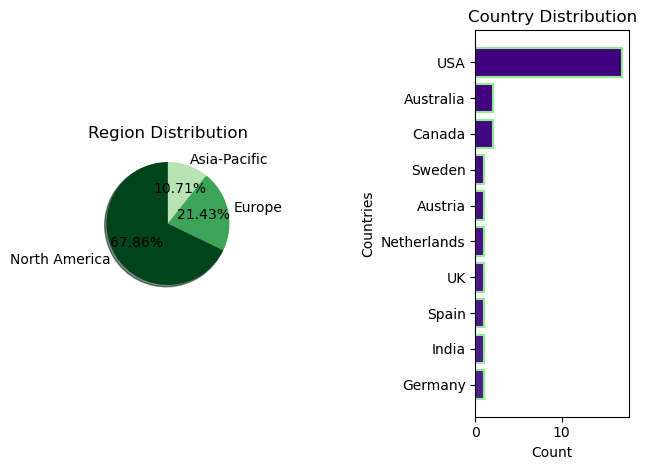

In [24]:
fig, ax = plt.subplots(1, 2)

ax[0].pie(
        data['region'].value_counts().values,
    labels = data['region'].value_counts().index,
    autopct = '%1.2f%%',
    colors = plt.cm.Greens(np.linspace(1, 0.3, 3)),
    startangle = 90,
    shadow = True
)
ax[0].set_title('Region Distribution')


ax[1].barh(
    y = data['country'].value_counts().index,
    width = data['country'].value_counts().values,
    color = plt.cm.Purples(np.linspace(1, 0.9, 10)),
    linewidth = 1.5,
    edgecolor = 'lightgreen'
)
ax[1].set_title('Country Distribution')
ax[1].set_ylabel('Countries')
ax[1].set_xlabel('Count')
ax[1].invert_yaxis()


plt.tight_layout()
plt.subplots_adjust(wspace = 1.5)
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Region wise, most of the companies are from North America, and USA most companies from USA.

<div>